Computing Collatz run lengths...


Computing sandbox run lengths...


Computing Markov null model run lengths...



Summary Statistics:
  Collatz  - mean: 1.996


  Sandbox  - mean: 1.948, std: 0.223


  Markov   - mean: 1.996, std: 1.410


fig11 done


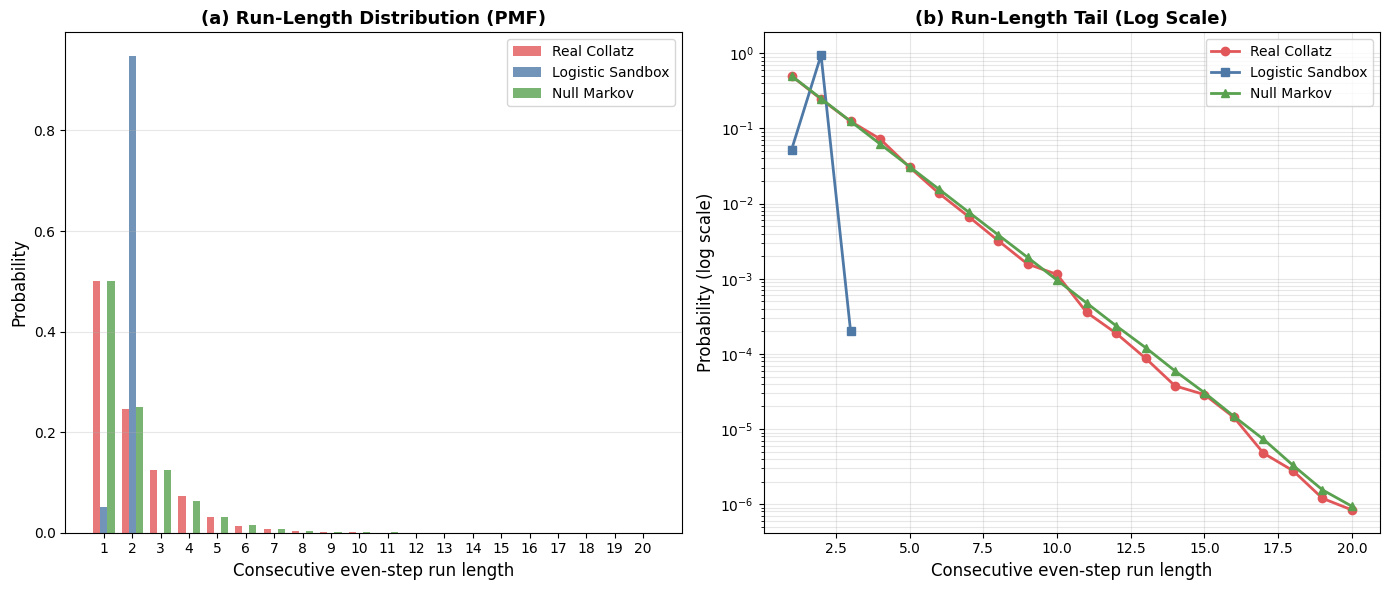

In [1]:
"""Fig 11: Run-length distribution comparison (consecutive even steps).
Compares: real Collatz, logistic sandbox, null Markov model."""
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from numba import njit

MU = 1.7548776662466927
X_STAR = (-1.0 + np.sqrt(1.0 + 4.0 * MU)) / (2.0 * MU)

# --- 1. Real Collatz run lengths ---
@njit
def collatz_run_lengths(nums, max_steps=2000):
    all_runs = np.zeros(max_steps, dtype=np.int64)
    total = 0
    for i in range(len(nums)):
        n = nums[i]
        run = 0
        while n > 1:
            if n % 2 == 0:
                n = n // 2
                run += 1
            else:
                if run > 0 and run < max_steps:
                    all_runs[run] += 1
                    total += 1
                run = 0
                n = 3 * n + 1
        if run > 0 and run < max_steps:
            all_runs[run] += 1
            total += 1
    return all_runs, total

# --- 2. Sandbox run lengths ---
def sandbox_run_lengths(n_samples=500000, max_iter=500):
    x = np.random.uniform(-1, 1, n_samples)
    runs = []
    current_run = np.zeros(n_samples, dtype=np.int32)
    for t in range(max_iter):
        state = (x >= X_STAR).astype(np.int32)
        is_zero = state == 0
        current_run[is_zero] += 1
        ended = (~is_zero) & (current_run > 0)
        runs.extend(current_run[ended].tolist())
        current_run[~is_zero] = 0
        x = 1.0 - MU * x**2
    return np.array(runs)

# --- 3. Null Markov run lengths ---
def markov_run_lengths(n_samples=500000, max_iter=500):
    state = np.random.choice([0, 1], size=n_samples, p=[2/3, 1/3])
    runs = []
    current_run = np.zeros(n_samples, dtype=np.int32)
    for t in range(max_iter):
        is_zero = state == 0
        current_run[is_zero] += 1
        ended = (~is_zero) & (current_run > 0)
        runs.extend(current_run[ended].tolist())
        current_run[~is_zero] = 0
        next_state = np.zeros(n_samples, dtype=np.int32)
        mask0 = state == 0
        next_state[mask0] = np.random.choice([0, 1], size=np.sum(mask0))
        next_state[~mask0] = 0
        state = next_state
    return np.array(runs)

N = 500000
print("Computing Collatz run lengths...")
nums = np.random.randint(10**11, 10**13, size=N, dtype=np.int64)
collatz_hist, collatz_total = collatz_run_lengths(nums)

print("Computing sandbox run lengths...")
sandbox_runs = sandbox_run_lengths(N)

print("Computing Markov null model run lengths...")
markov_runs = markov_run_lengths(N)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

max_len = 20

# (a) PMF comparison
collatz_pmf = collatz_hist[1:max_len+1] / collatz_total if collatz_total > 0 else np.zeros(max_len)
sandbox_counts = np.bincount(sandbox_runs, minlength=max_len+1)[1:max_len+1]
sandbox_pmf = sandbox_counts / len(sandbox_runs) if len(sandbox_runs) > 0 else np.zeros(max_len)
markov_counts = np.bincount(markov_runs, minlength=max_len+1)[1:max_len+1]
markov_pmf = markov_counts / len(markov_runs) if len(markov_runs) > 0 else np.zeros(max_len)

x_pos = np.arange(1, max_len+1)
w = 0.25
axes[0].bar(x_pos - w, collatz_pmf, width=w, color='#E15759', alpha=0.8, label='Real Collatz')
axes[0].bar(x_pos, sandbox_pmf, width=w, color='#4E79A7', alpha=0.8, label='Logistic Sandbox')
axes[0].bar(x_pos + w, markov_pmf, width=w, color='#59A14F', alpha=0.8, label='Null Markov')
axes[0].set_xlabel('Consecutive even-step run length', fontsize=12)
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].set_title('(a) Run-Length Distribution (PMF)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(x_pos)

# (b) Log-scale tail
for pmf, label, color, marker in [(collatz_pmf, 'Real Collatz', '#E15759', 'o'),
                                    (sandbox_pmf, 'Logistic Sandbox', '#4E79A7', 's'),
                                    (markov_pmf, 'Null Markov', '#59A14F', '^')]:
    valid = pmf > 0
    axes[1].semilogy(x_pos[valid], pmf[valid], marker=marker, color=color, linewidth=2, markersize=6, label=label)
axes[1].set_xlabel('Consecutive even-step run length', fontsize=12)
axes[1].set_ylabel('Probability (log scale)', fontsize=12)
axes[1].set_title('(b) Run-Length Tail (Log Scale)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

# Print summary stats
print(f"\nSummary Statistics:")
print(f"  Collatz  - mean: {np.sum(np.arange(1,max_len+1)*collatz_pmf)/np.sum(collatz_pmf):.3f}")
print(f"  Sandbox  - mean: {np.mean(sandbox_runs):.3f}, std: {np.std(sandbox_runs):.3f}")
print(f"  Markov   - mean: {np.mean(markov_runs):.3f}, std: {np.std(markov_runs):.3f}")

plt.tight_layout()
plt.savefig('fig11.png', dpi=300)
print("fig11 done")
